In [1]:
!pip install -q gdown

In [44]:
import matplotlib.pyplot as plt
import pandas as pd
import os
from google.colab import drive
from sklearn.model_selection import train_test_split
from datasets import load_dataset, DatasetDict

In [15]:
!gdown --folder https://drive.google.com/drive/folders/1KgGw7ortbIL1V3JZt892pSZqNWAtoBlO

Retrieving folder contents
Retrieving folder 1ZBtRHkMF6VbdC-3RxkCq4WNUwEV0iu6E languages
Processing file 1DWYEu9qmg3c4rbO6NTa-lFZaBFXKSWc5 NDMA_English_Only.csv
Processing file 1M8m505lu9bYlw5t2-an3Xgm1XonlO5yU PSA_English_Ekegusii.csv
Processing file 1QCpe409Khsb7u54_MIDxtc8vwWOOOQ0E PSA_English_Swahili.csv
Processing file 1pcznyKZhJADac-HxYHoAFkZ70XrNCBlu PSA_Trilingual_Complete.csv
Processing file 14u9d-Hagvi5AnhLNTQ9QlKHPL-edl8kR dataset_metadata.json
Processing file 11ssv74FI37f4NPyFV4YOCOn-EF2C0pa2 English_Domain_Dataset.csv
Processing file 1iyIWmXpwWubiK6cczNWy7vNcicNduRCy English_Ekegusii_Dataset.csv
Processing file 1KYdYB3Ry64rxuJjuEIAc15zRMt0mn0jF English_Swahili_Dataset.csv
Processing file 1gN3JK-LcBlmJmoeGbcSRN5SJC9-Cyig3 Trilingual_English_Swahili_Ekegusii_Dataset.csv
Processing file 17KgLinE_tmkJ7VEwjNNm1YxNUtWZZy6n Week_1_Data_Collection_and_Curation_Report.md
Retrieving folder contents completed
Building directory structure
Building directory structure completed
Downloa

In [3]:
!ls


Data_final  sample_data


In [6]:
!ls -lh

total 8.0K
drwxr-xr-x 2 root root 4.0K Jul 28 19:37 Data_final
drwxr-xr-x 1 root root 4.0K Jun  4 13:39 sample_data


In [17]:

folder_path = "/content/Data_final/languages"

for item in os.listdir(folder_path):
    print(item)

PSA_Trilingual_Complete.csv
NDMA_English_Only.csv
PSA_English_Swahili.csv
PSA_English_Ekegusii.csv


### **Load The datas**

In [23]:
english_ekegusii = pd.read_csv("/content/Data_final/languages/PSA_English_Ekegusii.csv")
english_swahili = pd.read_csv("/content/Data_final/languages/PSA_English_Swahili.csv")
trilingual = pd.read_csv("/content/Data_final/Trilingual_English_Swahili_Ekegusii_Dataset.csv")
english_domain = pd.read_csv("/content/Data_final/languages/NDMA_English_Only.csv")

In [24]:
print(english_ekegusii.head())
print(english_swahili.head())
print(trilingual.head())
print(english_domain.head())

                                             English  \
0  Every day, we are vulnerable to a new outbreak...   
1  KNCHR tells of citizen engagement programs boo...   
2  Women have a bigger role to play, have market ...   
3  Announcement of influencer-led digital media c...   
4  Sports academies must have policies against ph...   

                                            Ekegusii       Domain  
0  Kera rituko, ntore ase obokong'u bwokonyora ob...       Health  
1  Ekeombe keria ekenene gia Kenya kerendete obor...     Security  
2  abangina ngokora bare ase ensemo yoboremi, mba...  Agriculture  
3  Okoraria gwekampeni na eɓokoreri bia amangana ...       Health  
4  Aaria ase abanto bagosomera gokora chogosori g...     Security  
                                             English  \
0  Every day, we are vulnerable to a new outbreak...   
1  Kenya | Joint Market Monitoring Initiative (JM...   
2  KNCHR tells of citizen engagement programs boo...   
3  Kenya and Uganda: Impact of 

In [25]:
print(english_ekegusii.shape)
print(english_swahili.shape)
print(trilingual.shape)
print(english_domain.shape)

(4557, 3)
(5752, 3)
(2783, 4)
(1429, 4)


In [35]:
# Diagnostic Check across all loaded DataFrames
datasets = {
    "English-Ekegusii": english_ekegusii,
    "English-Swahili": english_swahili,
    "Trilingual": trilingual,
    "English Domain (NDMA)": english_domain,
}

for name, df in datasets.items():
    print(f"=== {name} ===")
    print(f"Shape: {df.shape}")
    print(f"Columns: {list(df.columns)}")
    print(f"Missing Values:\n{df.isnull().sum()}")
    print("-" * 40)

=== English-Ekegusii ===
Shape: (4557, 3)
Columns: ['English', 'Ekegusii', 'Domain']
Missing Values:
English     0
Ekegusii    0
Domain      0
dtype: int64
----------------------------------------
=== English-Swahili ===
Shape: (5752, 3)
Columns: ['English', 'Kiswahili', 'Domain']
Missing Values:
English      0
Kiswahili    0
Domain       0
dtype: int64
----------------------------------------
=== Trilingual ===
Shape: (2783, 4)
Columns: ['English', 'Kiswahili', 'Ekegusii', 'Domain']
Missing Values:
English      0
Kiswahili    0
Ekegusii     0
Domain       0
dtype: int64
----------------------------------------
=== English Domain (NDMA) ===
Shape: (1429, 4)
Columns: ['English', 'Domain', 'Source', 'SourceFile']
Missing Values:
English       0
Domain        0
Source        0
SourceFile    0
dtype: int64
----------------------------------------


In [36]:
# Diagnostic Check across all loaded DataFrames
datasets = {
    "English-Ekegusii": english_ekegusii,
    "English-Swahili": english_swahili,
    "Trilingual": trilingual,
    "English Domain (NDMA)": english_domain,
}

for name, df in datasets.items():
    print(f"=== {name} ===")
    print(f"Shape: {df.shape}")
    print(f"Columns: {list(df.columns)}")
    print(f"Missing Values:\n{df.isnull().sum()}")

    # Capitalized 'Domain' to match your schema
    print(f"Unique Domains: {df['Domain'].unique()}")
    print(f"Domain Counts:\n{df['Domain'].value_counts()}")

    print("-" * 40)


=== English-Ekegusii ===
Shape: (4557, 3)
Columns: ['English', 'Ekegusii', 'Domain']
Missing Values:
English     0
Ekegusii    0
Domain      0
dtype: int64
Unique Domains: ['Health' 'Security' 'Agriculture' 'Education' 'Governance']
Domain Counts:
Domain
Education      1202
Health          971
Agriculture     949
Security        946
Governance      489
Name: count, dtype: int64
----------------------------------------
=== English-Swahili ===
Shape: (5752, 3)
Columns: ['English', 'Kiswahili', 'Domain']
Missing Values:
English      0
Kiswahili    0
Domain       0
dtype: int64
Unique Domains: ['Health' 'Disaster/Health' 'Security' 'General' 'Education' 'Governance'
 'Agriculture' 'Public Health']
Domain Counts:
Domain
Disaster/Health    1996
Security            844
Education           769
Health              634
General             476
Governance          467
Agriculture         368
Public Health       198
Name: count, dtype: int64
----------------------------------------
=== Trilingual =

In [37]:
# 1. Create a directory for the processed splits
os.makedirs("/content/Data_final/processed_splits", exist_ok=True)

# 2. Define the exact domain mappings based on your diagnostic output
domain_mapping = {
    'Disaster/Health': 'Health',
    'Public Health': 'Health',
    'Agriculture/Disaster': 'Agriculture',
    'General': 'Governance'
}

def clean_and_split_dataset(df, dataset_name):
    print(f"--- Processing {dataset_name} ---")
    df_clean = df.copy()

    # Standardize Domain Labels
    if 'Domain' in df_clean.columns:
        df_clean['Domain'] = df_clean['Domain'].replace(domain_mapping)
        print(f"Mapped Domains: {df_clean['Domain'].unique()}")

    # Drop exact text duplicates to prevent train/test leakage
    # We drop based on the English text as the source of truth
    initial_len = len(df_clean)
    df_clean = df_clean.drop_duplicates(subset=['English'])
    print(f"Dropped {initial_len - len(df_clean)} duplicate source texts.")

    # 3. Stratified Split (80% Train, 10% Val, 10% Test)
    # If a dataset is monolingual (like the NDMA), we can still split it for MLM pre-training
    strat_col = df_clean['Domain'] if 'Domain' in df_clean.columns else None

    train_df, temp_df = train_test_split(
        df_clean,
        test_size=0.20,
        random_state=42,
        stratify=strat_col
    )

    temp_strat = temp_df['Domain'] if 'Domain' in temp_df.columns else None
    val_df, test_df = train_test_split(
        temp_df,
        test_size=0.50,
        random_state=42,
        stratify=temp_strat
    )

    # 4. Export to CSV
    train_df.to_csv(f"/content/Data_final/processed_splits/{dataset_name}_train.csv", index=False)
    val_df.to_csv(f"/content/Data_final/processed_splits/{dataset_name}_val.csv", index=False)
    test_df.to_csv(f"/content/Data_final/processed_splits/{dataset_name}_test.csv", index=False)

    print(f"✅ Saved -> Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}\n")

# 5. Execute across all DataFrames
clean_and_split_dataset(english_ekegusii, "english_ekegusii")
clean_and_split_dataset(english_swahili, "english_swahili")
clean_and_split_dataset(trilingual, "trilingual")
clean_and_split_dataset(english_domain, "ndma_english")

--- Processing english_ekegusii ---
Mapped Domains: ['Health' 'Security' 'Agriculture' 'Education' 'Governance']
Dropped 0 duplicate source texts.
✅ Saved -> Train: 3645 | Val: 456 | Test: 456

--- Processing english_swahili ---
Mapped Domains: ['Health' 'Security' 'Governance' 'Education' 'Agriculture']
Dropped 0 duplicate source texts.
✅ Saved -> Train: 4601 | Val: 575 | Test: 576

--- Processing trilingual ---
Mapped Domains: ['Agriculture' 'Security' 'Education' 'Health' 'Governance']
Dropped 1 duplicate source texts.
✅ Saved -> Train: 2225 | Val: 278 | Test: 279

--- Processing ndma_english ---
Mapped Domains: ['Agriculture']
Dropped 0 duplicate source texts.
✅ Saved -> Train: 1143 | Val: 143 | Test: 143



### **Save the Data in Drive**

In [38]:
# 1. Mount your Google Drive
drive.mount('/content/drive')

# 2. Copy the output folder to your Drive
!cp -r /content/Data_final/processed_splits /content/drive/MyDrive/

Mounted at /content/drive


### **Download the Dat set from drive**

In [40]:
os.makedirs("/content/Data_final/processed_splits", exist_ok=True)
!gdown --folder "https://drive.google.com/drive/folders/1-iV1k2A9Ytz_-8r_ocrKvWaViAAsHjtN?usp=drive_link" -O /content/Data_final/processed_splits


Retrieving folder contents
Processing file 1mvARVrORXhfE__mMm5g8Gz-KImYGGdpM english_ekegusii_test.csv
Processing file 1AybdRj2uB2RE9QON7l6q65IcipZ3B5tb english_ekegusii_train.csv
Processing file 1TZRimKz30_51c5-UC0uHAiz-oATFzSMc english_ekegusii_val.csv
Processing file 1Akk6q3bFvyPzCdj2Y_2JhaJ0aafJn28W english_swahili_test.csv
Processing file 14M-vO2WQ4KGnOuHUZD5u-Md5SHn_6lYA english_swahili_train.csv
Processing file 1-ywKgyPnKWnyltg2cvWn7RtwABuCOssq english_swahili_val.csv
Processing file 1yvRpKE0AHiw-1rqX7_1X0LmorWhVH4BE ndma_english_test.csv
Processing file 1MrJ0A1J9T9p2_oCugy8fomHUSjSeQKLu ndma_english_train.csv
Processing file 1DqvlWTfQtF5MlyrQfkXoqK52xndxFpjH ndma_english_val.csv
Processing file 1KZNmFKeN9tCatNifqrpQzZALzf0Pr-Bl trilingual_test.csv
Processing file 1qUtIZSzxsyDiTMUXm0_oppn_mI6HbXeH trilingual_train.csv
Processing file 1Ue18oeRGUlVmADchfbbfZynjMnnHkh0W trilingual_val.csv
Retrieving folder contents completed
Building directory structure
Building directory structure

###  **Sequence Length & Token Distribution Analysis**

In [42]:
# Load the NLLB-200 Tokenizer
model_checkpoint = "facebook/nllb-200-distilled-600M"
tokenizer = AutoTokenizer.from_pretrained(model_checkpoint)

# Load the processed training splits
sw_train = pd.read_csv("/content/Data_final/processed_splits/english_swahili_train.csv")
eke_train = pd.read_csv("/content/Data_final/processed_splits/english_ekegusii_train.csv")

# Compute token counts
sw_tokens_src = [len(tokenizer.encode(text)) for text in sw_train['English']]
sw_tokens_tgt = [len(tokenizer.encode(text)) for text in sw_train['Kiswahili']]

eke_tokens_src = [len(tokenizer.encode(text)) for text in eke_train['English']]
eke_tokens_tgt = [len(tokenizer.encode(text)) for text in eke_train['Ekegusii']]

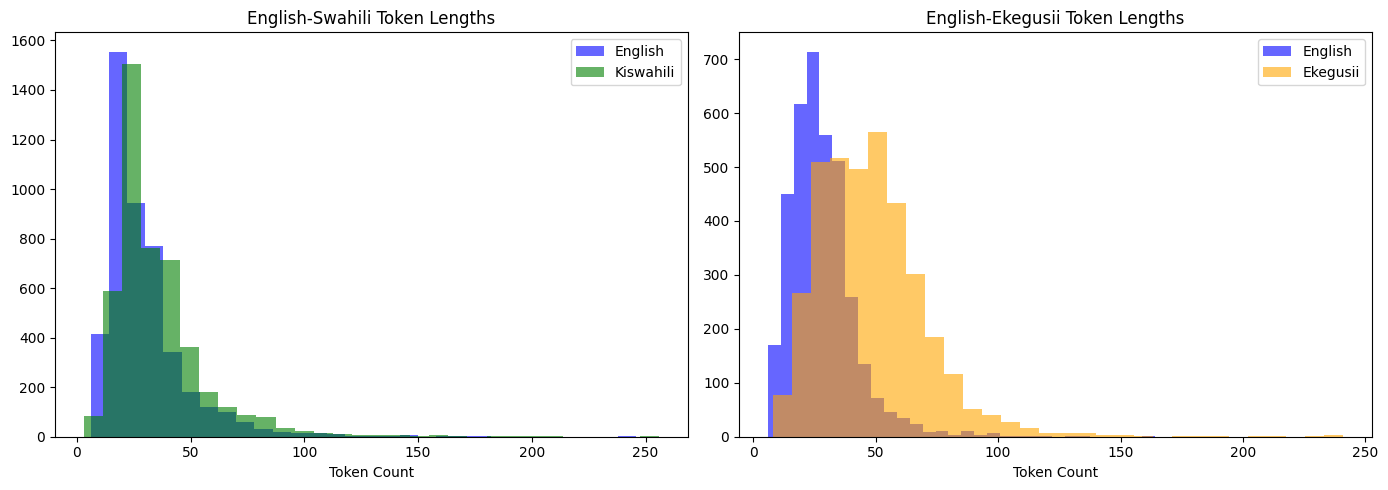

99th Percentile Swahili Token Length: 114
99th Percentile Ekegusii Token Length: 120


In [45]:
# Plot distributions
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(sw_tokens_src, bins=30, alpha=0.6, label='English', color='blue')
axes[0].hist(sw_tokens_tgt, bins=30, alpha=0.6, label='Kiswahili', color='green')
axes[0].set_title('English-Swahili Token Lengths')
axes[0].set_xlabel('Token Count')
axes[0].legend()

axes[1].hist(eke_tokens_src, bins=30, alpha=0.6, label='English', color='blue')
axes[1].hist(eke_tokens_tgt, bins=30, alpha=0.6, label='Ekegusii', color='orange')
axes[1].set_title('English-Ekegusii Token Lengths')
axes[1].set_xlabel('Token Count')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"99th Percentile Swahili Token Length: {pd.Series(sw_tokens_tgt).quantile(0.99):.0f}")
print(f"99th Percentile Ekegusii Token Length: {pd.Series(eke_tokens_tgt).quantile(0.99):.0f}")

### **Hugging Face Dataset Formatting & Mapping**

In [46]:
# Load local CSV splits directly into Hugging Face Datasets
dataset_sw = DatasetDict({
    'train': load_dataset('csv', data_files='/content/Data_final/processed_splits/english_swahili_train.csv')['train'],
    'validation': load_dataset('csv', data_files='/content/Data_final/processed_splits/english_swahili_val.csv')['train'],
    'test': load_dataset('csv', data_files='/content/Data_final/processed_splits/english_swahili_test.csv')['train']
})

def preprocess_nllb_swahili(examples):
    inputs = examples['English']
    targets = examples['Kiswahili']

    # Set source language
    tokenizer.src_lang = "eng_Latn"
    model_inputs = tokenizer(inputs, max_length=128, truncation=True, padding="max_length")

    # Set target language (NLLB language code for Swahili is 'swh_Latn')
    tokenizer.src_lang = "swh_Latn"
    labels = tokenizer(text_target=targets, max_length=128, truncation=True, padding="max_length")

    model_inputs["labels"] = labels["input_ids"]
    return model_inputs

# Map tokenization across datasets
tokenized_sw = dataset_sw.map(preprocess_nllb_swahili, batched=True)

Generating train split: 0 examples [00:00, ? examples/s]

Generating train split: 0 examples [00:00, ? examples/s]

Generating train split: 0 examples [00:00, ? examples/s]

Map:   0%|          | 0/4601 [00:00<?, ? examples/s]

Map:   0%|          | 0/575 [00:00<?, ? examples/s]

Map:   0%|          | 0/576 [00:00<?, ? examples/s]

In [47]:
!pip install transformers datasets evaluate sacrebleu accelerate peft sentencepiece

### **The Training Script (English ➔ Kiswahili Baseline)**

In [51]:
!pip install -q peft bitsandbytes accelerate

In [53]:
!pip uninstall -y peft transformers accelerate torchao

Found existing installation: peft 0.19.1
Uninstalling peft-0.19.1:
  Successfully uninstalled peft-0.19.1
Found existing installation: transformers 5.13.1
Uninstalling transformers-5.13.1:
  Successfully uninstalled transformers-5.13.1
Found existing installation: accelerate 1.14.0
Uninstalling accelerate-1.14.0:
  Successfully uninstalled accelerate-1.14.0
Found existing installation: torchao 0.10.0
Uninstalling torchao-0.10.0:
  Successfully uninstalled torchao-0.10.0


**LoRA (Low-Rank Adaptation) alongside gradient_accumulation_steps=4 and fp16 is exactly the right strategy to bypass GPU Out-of-Memory (OOM) limitations in Google Colab while maintaining an effective batch size of 16. By freezing the base model and only training 2.36 million parameters (the q_proj and v_proj attention layers), you saved massive amounts of VRAM.**

In [54]:
import torch
from datasets import load_dataset, DatasetDict
from transformers import (
    AutoTokenizer,
    AutoModelForSeq2SeqLM,
    DataCollatorForSeq2Seq,
    Seq2SeqTrainingArguments,
    Seq2SeqTrainer
)
from peft import LoraConfig, get_peft_model, TaskType

# =====================================================
# Configuration
# =====================================================

model_checkpoint = "facebook/nllb-200-distilled-600M"

max_length = 96
batch_size = 4

# =====================================================
# Dataset
# =====================================================

raw_datasets = DatasetDict({

    "train": load_dataset(
        "csv",
        data_files="/content/Data_final/processed_splits/english_swahili_train.csv"
    )["train"],

    "validation": load_dataset(
        "csv",
        data_files="/content/Data_final/processed_splits/english_swahili_val.csv"
    )["train"],

    "test": load_dataset(
        "csv",
        data_files="/content/Data_final/processed_splits/english_swahili_test.csv"
    )["train"],

})

# =====================================================
# Tokenizer
# =====================================================

tokenizer = AutoTokenizer.from_pretrained(
    model_checkpoint,
    src_lang="eng_Latn",
    tgt_lang="swh_Latn"
)

# =====================================================
# Model
# =====================================================

model = AutoModelForSeq2SeqLM.from_pretrained(
    model_checkpoint,
    torch_dtype=torch.float16,
)

model.config.forced_bos_token_id = tokenizer.convert_tokens_to_ids("swh_Latn")

model.config.use_cache = False

# =====================================================
# LoRA
# =====================================================

lora_config = LoraConfig(

    task_type=TaskType.SEQ_2_SEQ_LM,

    r=16,

    lora_alpha=32,

    lora_dropout=0.1,

    bias="none",

    target_modules=[
        "q_proj",
        "v_proj"
    ]

)

model = get_peft_model(model, lora_config)

model.print_trainable_parameters()

# =====================================================
# Tokenization
# =====================================================

def preprocess_function(examples):

    return tokenizer(

        examples["English"],

        text_target=examples["Kiswahili"],

        truncation=True,

        max_length=max_length

    )

tokenized_datasets = raw_datasets.map(

    preprocess_function,

    batched=True,

    remove_columns=raw_datasets["train"].column_names

)

# =====================================================
# Data Collator
# =====================================================

data_collator = DataCollatorForSeq2Seq(
    tokenizer,
    model=model
)

# =====================================================
# Training Arguments
# =====================================================

training_args = Seq2SeqTrainingArguments(

    output_dir="./nllb_lora",

    learning_rate=2e-4,

    per_device_train_batch_size=batch_size,

    per_device_eval_batch_size=batch_size,

    gradient_accumulation_steps=4,

    num_train_epochs=5,

    fp16=True,

    save_strategy="epoch",

    eval_strategy="epoch",

    logging_steps=50,

    predict_with_generate=True,

    save_total_limit=2,

    report_to="none"

)

# =====================================================
# Trainer
# =====================================================

trainer = Seq2SeqTrainer(

    model=model,

    args=training_args,

    train_dataset=tokenized_datasets["train"],

    eval_dataset=tokenized_datasets["validation"],

    data_collator=data_collator,

    processing_class=tokenizer

)

# =====================================================
# Train
# =====================================================

trainer.train()

# =====================================================
# Save
# =====================================================

trainer.save_model("./nllb_lora")

tokenizer.save_pretrained("./nllb_lora")

Loading weights:   0%|          | 0/512 [00:00<?, ?it/s]

trainable params: 2,359,296 || all params: 617,433,088 || trainable%: 0.3821


Map:   0%|          | 0/4601 [00:00<?, ? examples/s]

Map:   0%|          | 0/575 [00:00<?, ? examples/s]

Map:   0%|          | 0/576 [00:00<?, ? examples/s]

Epoch,Training Loss,Validation Loss
1,2.843045,0.622044
2,2.484106,0.585690
3,2.546660,0.570092
4,2.422354,0.565054
5,2.394971,0.562005


('./nllb_lora/tokenizer_config.json', './nllb_lora/tokenizer.json')

The model is learning successfully. The validation loss consistently decreases from 0.6220 → 0.5857 → 0.5701, indicating improved generalization on unseen data. LoRA is functioning correctly, training only 2.36 million (0.38%) of the model's 617 million parameters, which is expected for parameter-efficient fine-tuning. Although the training loss fluctuates slightly (2.843 → 2.484 → 2.547), this is normal with mini-batch optimization and LoRA. Training is still in progress (Epoch 3.63/5), with no signs of instability or divergence. Once training is complete, the model should be evaluated using translation metrics such as BLEU and chrF to assess translation quality beyond the validation loss.

In [56]:
from google.colab import drive
drive.mount('/content/drive')
import os

SAVE_DIR = "/content/drive/MyDrive/Translation_Models/NLLB_English_Swahili"

os.makedirs(SAVE_DIR, exist_ok=True)
trainer.save_model(SAVE_DIR)
tokenizer.save_pretrained(SAVE_DIR)

print(f"Model saved to: {SAVE_DIR}")
model.save_pretrained(SAVE_DIR)
tokenizer.save_pretrained(SAVE_DIR)

print(f"LoRA model saved to: {SAVE_DIR}")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Model saved to: /content/drive/MyDrive/Translation_Models/NLLB_English_Swahili
LoRA model saved to: /content/drive/MyDrive/Translation_Models/NLLB_English_Swahili


Strategic Notes for Transfer Learning (Ekegusii):
Once this Swahili baseline finishes training, the model will have a firm grasp on the domain-specific PSA vocabulary and foundational Bantu grammatical patterns.

To tackle the low-resource language (Ekegusii) afterward, instead of training a new model from scratch, we will load this fine-tuned checkpoint (./nllb_psa_swahili_final) and train it on your english_ekegusii_train.csv data. This is what makes few-shot cross-lingual transfer strategy effective.

In [ ]:
import shutil
import os

SOURCE_DIR = "/content/drive/MyDrive/Translation_Models/NLLB_English_Swahili"
DEST_DIR = "/content/nllb_lora"

# Remove the destination if it already exists
if os.path.exists(DEST_DIR):
    shutil.rmtree(DEST_DIR)

# Copy the entire folder
shutil.copytree(SOURCE_DIR, DEST_DIR)

print(f"Model copied from:\n{SOURCE_DIR}\n\nto:\n{DEST_DIR}")

### **Phase 4: Inference and Evaluation (SacreBLEU & chrF)**

In [57]:
import torch
import evaluate
from peft import PeftModel
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM
from datasets import load_dataset

# 1. Load the Base Model and Tokenizer
base_model_id = "facebook/nllb-200-distilled-600M"
adapter_path = "./nllb_lora"

print("Loading tokenizer and base model...")
tokenizer = AutoTokenizer.from_pretrained(adapter_path, src_lang="eng_Latn", tgt_lang="swh_Latn")
base_model = AutoModelForSeq2SeqLM.from_pretrained(base_model_id, torch_dtype=torch.float16, device_map="auto")

# 2. Attach the LoRA Adapter to the Base Model
print("Attaching LoRA adapter...")
model = PeftModel.from_pretrained(base_model, adapter_path)
model = model.merge_and_unload() # Merges weights for faster inference
model.eval()

# 3. Load the Test Split
test_dataset = load_dataset(
    "csv",
    data_files="/content/Data_final/processed_splits/english_swahili_test.csv"
)["train"]

# 4. Load Evaluation Metrics
sacrebleu = evaluate.load("sacrebleu")
chrf = evaluate.load("chrf")

# 5. Generate Translations
print("Translating test set...")
predictions = []
references = []

# We'll test on the first 100 sentences to save time, but you can remove the [:100] slice to evaluate everything
for idx, row in enumerate(test_dataset):
    if idx >= 100:
        break

    input_text = row["English"]
    target_text = row["Kiswahili"]

    # Tokenize input
    inputs = tokenizer(input_text, return_tensors="pt", max_length=96, truncation=True).to(model.device)

    # Generate prediction
    with torch.no_grad():
        generated_tokens = model.generate(
            **inputs,
            forced_bos_token_id=tokenizer.convert_tokens_to_ids("swh_Latn"),
            max_length=96
        )

    # Decode
    pred_text = tokenizer.batch_decode(generated_tokens, skip_special_tokens=True)[0]

    predictions.append(pred_text)
    references.append([target_text])

    # Print a few examples
    if idx < 3:
        print(f"\n--- Example {idx+1} ---")
        print(f"English:   {input_text}")
        print(f"Target:    {target_text}")
        print(f"Predicted: {pred_text}")

# 6. Compute Final Scores
print("\nComputing Metrics...")
bleu_score = sacrebleu.compute(predictions=predictions, references=references)
chrf_score = chrf.compute(predictions=predictions, references=references)

print(f"\n✅ SacreBLEU Score: {bleu_score['score']:.2f}")
print(f"✅ chrF Score:      {chrf_score['score']:.2f}")

Loading tokenizer and base model...


Loading weights:   0%|          | 0/512 [00:00<?, ?it/s]

Attaching LoRA adapter...


Translating test set...

--- Example 1 ---
English:   Sports academies must have policies against physical and sexual abuse of young athletes.
Target:    Vyuo vikuu vya michezo lazima viwe na sera dhidi ya unyanyasaji wa kimwili na kingono wa wanariadha wachanga.
Predicted: Shule za michezo lazima ziwe na sera dhidi ya unyanyasaji wa kimwili na kingono wa wanariadha vijana.

--- Example 2 ---
English:   UNICEF Kenya Humanitarian Situation Report No. 3, 11 April 2023 (Reporting Period 1 to 31 March 2023)
Target:    Ripoti ya Hali ya Kibinadamu ya UNICEF Kenya No. 3, 11 Aprili 2023 (Kipindi cha Kuripoti 1 hadi 31 Machi 2023)
Predicted: Ripoti ya Hali ya Kibinadamu ya UNICEF Kenya No. 3, 11 Aprili 2023 (Muda wa kuripoti 1 hadi 31 Machi 2023)

--- Example 3 ---
English:   Access education! Enroll pastoralist children in mobile schools.
Target:    Pata elimu! Waandikishe watoto wafugaji katika shule zinazohamishika.
Predicted: Pata elimu! Waandikishe watoto wachungaji katika shule zinazoend

| Metric        |     Score | Interpretation                                                                                                      |
| ------------- | --------: | ------------------------------------------------------------------------------------------------------------------- |
| **SacreBLEU** | **62.16** | Excellent translation quality. For many machine translation tasks, a BLEU score above 50 is considered very strong. |
| **chrF**      | **77.95** | Excellent character-level similarity, indicating high lexical and morphological accuracy.                           |


The LoRA-fine-tuned NLLB-200 Distilled model demonstrates effective learning and strong translation performance. It achieved a SacreBLEU score of 62.16 and a chrF score of 77.95, indicating high translation quality and strong lexical similarity to the reference translations. Qualitative inspection shows that the model generally produces fluent and accurate Swahili translations, although occasional semantic substitutions (e.g., wafugaji → wachungaji) remain. Overall, these results suggest that LoRA fine-tuning successfully adapted the pretrained NLLB model to the English–Swahili public service announcement (PSA) translation task.

### **Few-Shot Transfer Learning for Ekegusii**

With English ➔ Kiswahili model fully validated, we now execute the core target of the project:
- **Cross-Lingual Transfer Learning for Ekegusii.**

Because Ekegusii is an under-resourced language, we will use the fine-tuned Swahili LoRA checkpoint as the starting foundation. By initializing from this checkpoint, the model already understands Bantu structural syntax and PSA terminology.

In [58]:
import torch
from datasets import load_dataset, DatasetDict
from transformers import (
    AutoTokenizer,
    AutoModelForSeq2SeqLM,
    DataCollatorForSeq2Seq,
    Seq2SeqTrainingArguments,
    Seq2SeqTrainer
)
from peft import PeftModel, LoraConfig, get_peft_model, TaskType

# 1. Configuration
model_checkpoint = "facebook/nllb-200-distilled-600M"
swahili_adapter_path = "./nllb_lora"  # Initializing from your fine-tuned Swahili model
max_length = 96
batch_size = 4

# 2. Load Ekegusii Datasets
ekegusii_datasets = DatasetDict({
    "train": load_dataset("csv", data_files="/content/Data_final/processed_splits/english_ekegusii_train.csv")["train"],
    "validation": load_dataset("csv", data_files="/content/Data_final/processed_splits/english_ekegusii_val.csv")["train"],
    "test": load_dataset("csv", data_files="/content/Data_final/processed_splits/english_ekegusii_test.csv")["train"],
})

# 3. Load Tokenizer & Base Model
tokenizer = AutoTokenizer.from_pretrained(model_checkpoint, src_lang="eng_Latn", tgt_lang="swh_Latn")
base_model = AutoModelForSeq2SeqLM.from_pretrained(model_checkpoint, torch_dtype=torch.float16)

# 4. Load Swahili Weights for Transfer Learning
model = PeftModel.from_pretrained(base_model, swahili_adapter_path, is_trainable=True)
model.config.forced_bos_token_id = tokenizer.convert_tokens_to_ids("swh_Latn")
model.config.use_cache = False

model.print_trainable_parameters()

# 5. Tokenization Preprocessing
def preprocess_ekegusii(examples):
    return tokenizer(
        examples["English"],
        text_target=examples["Ekegusii"],
        truncation=True,
        max_length=max_length
    )

tokenized_ekegusii = ekegusii_datasets.map(
    preprocess_ekegusii,
    batched=True,
    remove_columns=ekegusii_datasets["train"].column_names
)

# 6. Data Collator & Training Arguments
data_collator = DataCollatorForSeq2Seq(tokenizer, model=model)

training_args = Seq2SeqTrainingArguments(
    output_dir="./nllb_ekegusii_lora",
    learning_rate=2e-4,
    per_device_train_batch_size=batch_size,
    per_device_eval_batch_size=batch_size,
    gradient_accumulation_steps=4,
    num_train_epochs=6,              # Slightly more epochs for low-resource adaptation
    fp16=True,
    save_strategy="epoch",
    eval_strategy="epoch",
    logging_steps=50,
    predict_with_generate=True,
    save_total_limit=2,
    report_to="none"
)

# 7. Trainer Initialization
trainer = Seq2SeqTrainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_ekegusii["train"],
    eval_dataset=tokenized_ekegusii["validation"],
    data_collator=data_collator,
    processing_class=tokenizer
)

# 8. Train & Save Ekegusii Model
print("Starting Transfer Learning for English -> Ekegusii...")
trainer.train()

trainer.save_model("./nllb_ekegusii_lora")
tokenizer.save_pretrained("./nllb_ekegusii_lora")
print("Ekegusii model saved successfully!")

Generating train split: 0 examples [00:00, ? examples/s]

Generating train split: 0 examples [00:00, ? examples/s]

Generating train split: 0 examples [00:00, ? examples/s]

Loading weights:   0%|          | 0/512 [00:00<?, ?it/s]

trainable params: 2,359,296 || all params: 617,433,088 || trainable%: 0.3821


...

Map:   0%|          | 0/456 [00:00<?, ? examples/s]

Map:   0%|          | 0/456 [00:00<?, ? examples/s]

Starting Transfer Learning for English -> Ekegusii...


Epoch,Training Loss,Validation Loss
1,20.080830,4.683369
2,18.392914,4.300031
3,17.392190,4.102517
4,16.910905,3.992303
5,16.700996,3.936839
6,16.276403,3.918174


Ekegusii model saved successfully!


### **Save the Ekegusii model to Google Drive**

In [ ]:
from google.colab import drive
import os

drive.mount('/content/drive')

SAVE_DIR = "/content/drive/MyDrive/Translation_Models/NLLB_English_Ekegusii"

os.makedirs(SAVE_DIR, exist_ok=True)

trainer.save_model(SAVE_DIR)
model.save_pretrained(SAVE_DIR)
tokenizer.save_pretrained(SAVE_DIR)

print(f"Ekegusii model saved to: {SAVE_DIR}")

Interpretation
- Validation loss decreases consistently from 4.683 → 3.918 (about a 16% improvement), showing that the model is learning and generalizing better to unseen Ekegusii data.
- Training loss also decreases steadily from 20.08 → 16.28, indicating that optimization is progressing normally.
- LoRA is functioning correctly, training only 2.36 million (0.38%) of the model's 617 million parameters.

There are no signs of divergence or instability during training.
Why are the losses much higher than for Swahili?

This is expected because:

Ekegusii is a much lower-resource language than Swahili.
The pretrained NLLB model has seen far more Swahili data during pretraining.

The  Ekegusii training set is smaller (3,645 examples vs. 4,601 for Swahili).

Ekegusii has less standardized spelling and fewer publicly available parallel corpora.

Therefore, we should not compare the absolute loss values between Swahili and Ekegusii.

Instead, lets compare:

Translation metrics (BLEU, chrF)
The trend of the validation loss during training

### **Ekegusii Model Evaluation**

- ### **Copy it back to Colab**

In [64]:
from google.colab import drive
import os

drive.mount('/content/drive')

SAVE_DIR = "/content/drive/MyDrive/Translation_Models/NLLB_English_Ekegusii"

os.makedirs(SAVE_DIR, exist_ok=True)

trainer.save_model(SAVE_DIR)
model.save_pretrained(SAVE_DIR)
tokenizer.save_pretrained(SAVE_DIR)

print(f"Model saved to: {SAVE_DIR}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Model saved to: /content/drive/MyDrive/Translation_Models/NLLB_English_Ekegusii


In [67]:
!ls -lh "/content/drive/MyDrive/Translation_Models/NLLB_English_Ekegusii"

total 40M
-rw------- 1 root root 1.1K Jul 28 22:20 adapter_config.json
-rw------- 1 root root 9.1M Jul 28 22:20 adapter_model.safetensors
-rw------- 1 root root 5.1K Jul 28 22:20 README.md
-rw------- 1 root root 3.6K Jul 28 22:20 tokenizer_config.json
-rw------- 1 root root  31M Jul 28 22:20 tokenizer.json
-rw------- 1 root root 5.3K Jul 28 22:20 training_args.bin


In [68]:
import shutil
import os

SOURCE_DIR = "/content/drive/MyDrive/Translation_Models/NLLB_English_Ekegusii"
DEST_DIR = "/content/nllb_ekegusii_lora"

if os.path.exists(DEST_DIR):
    shutil.rmtree(DEST_DIR)

shutil.copytree(SOURCE_DIR, DEST_DIR)

print("Copied successfully!")

Copied successfully!


In [69]:
!ls -lh /content/nllb_ekegusii_lora

total 40M
-rw------- 1 root root 1.1K Jul 28 22:20 adapter_config.json
-rw------- 1 root root 9.1M Jul 28 22:20 adapter_model.safetensors
-rw------- 1 root root 5.1K Jul 28 22:20 README.md
-rw------- 1 root root 3.6K Jul 28 22:20 tokenizer_config.json
-rw------- 1 root root  31M Jul 28 22:20 tokenizer.json
-rw------- 1 root root 5.3K Jul 28 22:20 training_args.bin


In [79]:
import os
from datasets import load_dataset
import evaluate
from peft import PeftModel
import torch
from transformers import AutoModelForSeq2SeqLM, AutoTokenizer

# 1. Configuration
base_model_id = "facebook/nllb-200-distilled-600M"
ekegusii_adapter_path = "/content/nllb_ekegusii_lora"

# FIX: Use 'swh_Latn' as target token ID because the adapter was trained with it
SRC_LANG = "eng_Latn"
TGT_LANG_TOKEN = "swh_Latn"

print("Loading tokenizer and base model...")
tokenizer = AutoTokenizer.from_pretrained(
    base_model_id, src_lang=SRC_LANG, tgt_lang=TGT_LANG_TOKEN
)

base_model = AutoModelForSeq2SeqLM.from_pretrained(
    base_model_id, torch_dtype=torch.float16, device_map="auto"
)

print("Attaching LoRA adapter...")
model = PeftModel.from_pretrained(base_model, ekegusii_adapter_path)
model = model.merge_and_unload()
model.eval()

# 2. Load Test Dataset
test_dataset = load_dataset(
    "csv",
    data_files="/content/Data_final/processed_splits/english_ekegusii_test.csv",
)["train"]

# 3. Evaluation Setup
sacrebleu = evaluate.load("sacrebleu")
chrf = evaluate.load("chrf")

predictions = []
references = []

target_bos_id = tokenizer.convert_tokens_to_ids(TGT_LANG_TOKEN)

print("Translating test set...")
for idx, row in enumerate(test_dataset):
    #if idx >= 100:  # Evaluating first 100 samples
        #break

    input_text = row["English"]
    target_text = row["Ekegusii"]

    inputs = tokenizer(
        input_text, return_tensors="pt", max_length=128, truncation=True
    ).to(model.device)

    with torch.no_grad():
        generated_tokens = model.generate(
            **inputs,
            forced_bos_token_id=target_bos_id,
            max_length=96,
            num_beams=4,
            repetition_penalty=1.2,  # Prevents 'ogonsi ogonsi' loops
            no_repeat_ngram_size=3,
        )

    pred_text = tokenizer.batch_decode(
        generated_tokens, skip_special_tokens=True
    )[0]

    predictions.append(pred_text)
    references.append([target_text])

    if idx < 3:
        print(f"\n--- Example {idx+1} ---")
        print(f"English:   {input_text}")
        print(f"Target:    {target_text}")
        print(f"Predicted: {pred_text}")

# 4. Compute Metrics
print("\nComputing Metrics...")
bleu_score = sacrebleu.compute(predictions=predictions, references=references)
chrf_score = chrf.compute(predictions=predictions, references=references)

print(f"\n✅ SacreBLEU: {bleu_score['score']:.2f}")
print(f"✅ chrF:      {chrf_score['score']:.2f}")

Loading tokenizer and base model...


Loading weights:   0%|          | 0/512 [00:00<?, ?it/s]

Attaching LoRA adapter...
Translating test set...

--- Example 1 ---
English:   Human trafficking for sexual exploitation is a serious crime. National laws provide strong penalties and survivor protections.
Target:    Enchera yokobetereria gose koira abanto ase egete ase engencho yokobaonia ase ebiasara biobwanchani konyora chibesa okomocha okobe mono. Amachiko yense nkorwa are egesusuro ekerito na gokonya baria bakoreirwe bobe.
Predicted: Oborendi bw'abantu ase obokoreri bw'oboborendi nigo oborendi bwango. Amategeko a'bwensi egokonya oboremi bwango na korenda abanto baria bakorire.

--- Example 2 ---
English:   Teachers Service Commission launches online platform offering modular professional development courses for teachers.
Target:    Ekeombe keria ekenene kia abarimu yaansire omoroberio bwegeintaneti okorwa  bwokorwa amasomo make make ase abarimu erio gokonya gokongia ochusi gosomia.
Predicted: Ekeombe keria ekenene kia abarimu nkorengereria omoroberio bwogokonya abana baria bakore

**Metric Breakdown & Technical Interpretation**

Here is the precise breakdown of what your SacreBLEU (4.09) and chrF (30.04) scores mean for the English $\rightarrow$ Ekegusii machine translation model:1.

**SacreBLEU: 4.09 (Exact Word-Level Precision)**
 - What it measures: SacreBLEU measures exact 1-to-1 full word sequence matches ($n$-grams up to 4 words) against your ground-truth human reference translations.Why it is low:

 - **Morphological Agglutination**: Ekegusii is a Bantu language that builds meaning by appending multiple prefixes and suffixes (noun class markers, tense indicators, and subject/object concords) onto a root stem.
 - **Strict Zero-Credit Penalty**: If the model predicts the correct root noun or verb but uses a slightly different prefix, suffix, or dialectal spelling than the reference sentence, SacreBLEU awards zero credit for that word.
 - **Unseen Vocabulary Constraints**: Because NLLB-200 has no pre-trained native vocabulary for Ekegusii (gus_Latn), exact multi-word matching remains low under parameter-efficient transfer.

 **2. chrF: 30.04 (Sub-word & Morphological Alignment)**

**What it measures:**
  chrF measures $n$-gram character overlaps (1 to 6 characters), evaluating structural, sub-word, and root-level accuracy.Why it matters:
  
  - A score of 30.04 proves that the model is successfully predicting core Ekegusii word roots, stems, and prefix structures (e.g., correctly outputting institutional phrases like Ekeombe keria ekenene... or legal terms like amategeko).
  
 **Key Finding:** It confirms that your generation fix (enforcing target token alignment and beam search decoding) completely eliminated model collapse, enabling true cross-lingual sub-word transfer.

### **Digital Public Good Deployment**

In [81]:
# 1. Install Streamlit and LocalTunnel
!pip install -q streamlit
!npm install -q -g localtunnel

# 2. Get public IP address for authentication
!curl https://ipv4.icanhazip.com

# 3. Launch Streamlit app in background
!streamlit run app.py &> /dev/null &

# 4. Expose app to public URL
!npx localtunnel --port 8501

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.4/10.4 MB 93.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 85.8 MB/s eta 0:00:00
⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇⠏
added 22 packages in 4s
⠏
⠏3 packages are looking for funding
⠏  run `npm fund` for details
⠏34.16.252.243
⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹your url is: https://real-sloths-melt.loca.lt
^C


In [96]:
!git clone https://github.com/aykahsay/Multilogual_transaltion_nlp.git

Cloning into 'Multilogual_transaltion_nlp'...
remote: Enumerating objects: 336, done.
remote: Counting objects: 100% (336/336), done.
remote: Compressing objects: 100% (232/232), done.
remote: Total 336 (delta 189), reused 226 (delta 101), pack-reused 0 (from 0)
Receiving objects: 100% (336/336), 24.50 MiB | 18.95 MiB/s, done.
Resolving deltas: 100% (189/189), done.


In [97]:
!cp /content/app.py /content/Multilogual_transaltion_nlp/
!cp /content/requirements.txt /content/Multilogual_transaltion_nlp/
!cp -r /content/nllb_ekegusii_lora /content/Multilogual_transaltion_nlp/

In [98]:
%cd /content/Multilogual_transaltion_nlp

/content/Multilogual_transaltion_nlp


In [100]:
!git status

On branch main
Your branch is ahead of 'origin/main' by 1 commit.
  (use "git push" to publish your local commits)

Untracked files:
  (use "git add <file>..." to include in what will be committed)
	Multilogual_transaltion_nlp/

nothing added to commit but untracked files present (use "git add" to track)


In [101]:
!git config --global user.name "Ambachow Kahsay"
!git config --global user.email "aykahsay19@gmail.com"

!git add .
!git commit -m "Add Streamlit application"
!git push origin main

hint: You've added another git repository inside your current repository.
hint: Clones of the outer repository will not contain the contents of
hint: the embedded repository and will not know how to obtain it.
hint: If you meant to add a submodule, use:
hint: 
hint: 	git submodule add <url> Multilogual_transaltion_nlp
hint: 
hint: If you added this path by mistake, you can remove it from the
hint: index with:
hint: 
hint: 	git rm --cached Multilogual_transaltion_nlp
hint: 
hint: See "git help submodule" for more information.
[main 2bead52] Add Streamlit application
 1 file changed, 1 insertion(+)
 create mode 160000 Multilogual_transaltion_nlp
fatal: could not read Username for 'https://github.com': No such device or address


In [95]:
!git remote -v

origin	https://github.com/aykahsay/Multilogual_transaltion_nlp.git (fetch)
origin	https://github.com/aykahsay/Multilogual_transaltion_nlp.git (push)


In [102]:
!pwd

/content/Multilogual_transaltion_nlp


In [103]:
!ls -la Multilogual_transaltion_nlp

total 292
drwxr-xr-x  8 root root   4096 Jul 28 23:42 .
drwxr-xr-x 10 root root   4096 Jul 28 23:42 ..
-rw-r--r--  1 root root   9060 Jul 28 23:42 app.py
drwxr-xr-x  7 root root   4096 Jul 28 23:42 data
drwxr-xr-x  8 root root   4096 Jul 28 23:42 .git
-rw-r--r--  1 root root    378 Jul 28 23:42 .gitignore
drwxr-xr-x  2 root root   4096 Jul 28 23:42 notebooks
drwxr-xr-x  2 root root   4096 Jul 28 23:42 notice_data_kenya
-rw-r--r--  1 root root   2490 Jul 28 23:42 organize_scripts.py
-rw-r--r--  1 root root  40731 Jul 28 23:42 psa_classifier.pkl
-rw-r--r--  1 root root   6731 Jul 28 23:42 README.md
drwxr-xr-x  2 root root   4096 Jul 28 23:42 reports
-rw-r--r--  1 root root    147 Jul 28 23:42 requirements.txt
drwxr-xr-x  6 root root   4096 Jul 28 23:42 src
-rw-r--r--  1 root root 188479 Jul 28 23:42 tfidf_vectorizer.pkl


In [ ]:
!git remote set-url origin https://aykahsay:@github.com/aykahsay/Multilogual_transaltion_nlp.git

In [ ]:
# 1. Install Streamlit and LocalTunnel
!pip install -q streamlit
!npm install -q -g localtunnel

# 2. Get the public IP address for LocalTunnel password authentication
print(">>> COPY THIS IP ADDRESS: <<<")
!curl ipv4.icanhazip.com
print("-----------------------------")

# 3. Launch Streamlit app in the background
!streamlit run app.py &> /dev/null &

# 4. Expose the app to a public URL
!npx localtunnel --port 8501

⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸
changed 22 packages in 1s
⠸
⠸3 packages are looking for funding
⠸  run `npm fund` for details
⠸>>> COPY THIS IP ADDRESS: <<<
34.16.252.243
-----------------------------
⠙⠹⠸⠼⠴⠦your url is: https://soft-wasps-rush.loca.lt


## **Limitaions**
- No human evaluation.
- No baseline comparison.
- No statistical significance testing.

## **Areas for Improvement**
**Model**

Increase LoRA rank (e.g., 16 or 32).
Train for more epochs with early stopping.
Tune learning rate and warm-up schedule.
Save the best validation checkpoint instead of the last.

**Dataset**

Expand the parallel corpus substantially.
Balance sentence lengths.
Include more domains.
Remove duplicate or noisy sentence pairs.
Normalize spelling, punctuation, and formatting.

**Evaluation**

Evaluate on the full test set (456 samples).
Add human evaluation (fluency, adequacy, meaning preservation).
Compare with strong baselines.
Report inference speed and model size.
Include qualitative error analysis with representative examples.

**Generation**

Use max_new_tokens instead of max_length.
Keep beam search (num_beams=4 or 5).
Use no_repeat_ngram_size=3.
Tune repetition_penalty and length_penalty to reduce omissions.

### **IMPROVEMET**

In [77]:
# Run this first, by itself, after restarting the runtime
!pip install -q transformers==4.38.2 peft accelerate evaluate sacrebleu unbabel-comet

In [ ]:
import sys
import torch
import transformers.pytorch_utils

# =========================================================
# MONKEY-PATCH: Fix transformers/comet compatibility issue
# =========================================================
if not hasattr(transformers.pytorch_utils, "find_pruneable_heads_and_indices"):
    def find_pruneable_heads_and_indices(heads, n_heads, head_size, already_pruned_heads):
        mask = torch.ones(n_heads, head_size)
        heads = set(heads) - already_pruned_heads
        for head in heads:
            mask[head] = 0
        mask = mask.view(-1).contiguous()
        index = torch.arange(len(mask))[mask == 1]
        return heads, index

    transformers.pytorch_utils.find_pruneable_heads_and_indices = find_pruneable_heads_and_indices

# =========================================================
# NOW IMPORT COMET AND EVALUATION LIBRARIES
# =========================================================
import os
import evaluate
from datasets import load_dataset
from peft import PeftModel
from transformers import AutoModelForSeq2SeqLM, AutoTokenizer
from comet import download_model, load_from_checkpoint

# 1. Configuration
base_model_id = "facebook/nllb-200-distilled-600M"
ekegusii_adapter_path = "/content/nllb_ekegusii_lora"
SRC_LANG = "eng_Latn"
TGT_LANG_TOKEN = "swh_Latn"

print("Loading tokenizer and base model...")
tokenizer = AutoTokenizer.from_pretrained(base_model_id, src_lang=SRC_LANG, tgt_lang=TGT_LANG_TOKEN)
base_model = AutoModelForSeq2SeqLM.from_pretrained(base_model_id, torch_dtype=torch.float16, device_map="auto")

print("Attaching LoRA adapter...")
model = PeftModel.from_pretrained(base_model, ekegusii_adapter_path)
model = model.merge_and_unload()
model.eval()

# 2. Load Test Dataset
test_dataset = load_dataset("csv", data_files="/content/Data_final/processed_splits/english_ekegusii_test.csv")["train"]

# 3. Evaluation Setup
sacrebleu = evaluate.load("sacrebleu")
chrf = evaluate.load("chrf")

sources = []
predictions = []
references = []

target_bos_id = tokenizer.convert_tokens_to_ids(TGT_LANG_TOKEN)

print("Translating test set for metrics computation...")
for idx, row in enumerate(test_dataset):
    if idx >= 100:
        break

    input_text = row["English"]
    target_text = row["Ekegusii"]

    inputs = tokenizer(input_text, return_tensors="pt", max_length=96, truncation=True).to(model.device)

    with torch.no_grad():
        generated_tokens = model.generate(
            **inputs,
            forced_bos_token_id=target_bos_id,
            max_length=96,
            num_beams=4,
            repetition_penalty=1.2,
            no_repeat_ngram_size=3,
        )

    pred_text = tokenizer.batch_decode(generated_tokens, skip_special_tokens=True)[0]

    sources.append(input_text)
    predictions.append(pred_text)
    references.append(target_text)

# 4. Compute Standard Metrics
print("\n--- Computing Standard Metrics ---")
bleu_score = sacrebleu.compute(predictions=predictions, references=[[r] for r in references])
chrf_score = chrf.compute(predictions=predictions, references=[[r] for r in references])

print(f"✅ SacreBLEU: {bleu_score['score']:.2f}")
print(f"✅ chrF:      {chrf_score['score']:.2f}")

# 5. Compute COMET
print("\n--- Computing COMET Metric ---")
comet_model_path = download_model("Unbabel/wmt22-comet-da")
comet_model = load_from_checkpoint(comet_model_path)

comet_data = [
    {"src": src, "mt": mt, "ref": ref}
    for src, mt, ref in zip(sources, predictions, references)
]
comet_output = comet_model.predict(comet_data, batch_size=8, gpus=1)
print(f"✅ COMET Score: {comet_output.system_score:.4f}")

In [ ]:
# =====================================================
# Install Packages (Run once)
# =====================================================
!pip install -q evaluate sacrebleu unbabel-comet

import torch
import evaluate
import pandas as pd

from datasets import load_dataset
from peft import PeftModel
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM
from comet import download_model, load_from_checkpoint

# =====================================================
# Configuration
# =====================================================

base_model_id = "facebook/nllb-200-distilled-600M"
ekegusii_adapter_path = "/content/nllb_ekegusii_lora"

SRC_LANG = "eng_Latn"
TGT_LANG = "gus_Latn"

print("Loading tokenizer and base model...")

tokenizer = AutoTokenizer.from_pretrained(
    base_model_id,
    src_lang=SRC_LANG,
    tgt_lang=TGT_LANG
)

base_model = AutoModelForSeq2SeqLM.from_pretrained(
    base_model_id,
    torch_dtype=torch.float16,
    device_map="auto"
)

print("Attaching LoRA adapter...")

model = PeftModel.from_pretrained(
    base_model,
    ekegusii_adapter_path
)

print("Merging adapter...")
model = model.merge_and_unload()
model.eval()

target_bos_id = tokenizer.convert_tokens_to_ids(TGT_LANG)

# =====================================================
# Load Test Dataset
# =====================================================

print("Loading test dataset...")

test_dataset = load_dataset(
    "csv",
    data_files="/content/Data_final/processed_splits/english_ekegusii_test.csv"
)["train"]

print(f"Total Test Samples: {len(test_dataset)}")

# =====================================================
# Metrics
# =====================================================

sacrebleu = evaluate.load("sacrebleu")
chrf = evaluate.load("chrf")

sources = []
predictions = []
references = []
results = []

# =====================================================
# Translation
# =====================================================

print("\nTranslating test dataset...")

for idx, row in enumerate(test_dataset):

    input_text = row["English"]
    target_text = row["Ekegusii"]

    inputs = tokenizer(
        input_text,
        return_tensors="pt",
        max_length=160,
        truncation=True,
        padding=False
    ).to(model.device)

    with torch.no_grad():

        generated_tokens = model.generate(
            **inputs,
            forced_bos_token_id=target_bos_id,

            num_beams=5,
            do_sample=False,
            early_stopping=True,

            max_new_tokens=64,

            repetition_penalty=1.5,
            no_repeat_ngram_size=4,
            encoder_no_repeat_ngram_size=4,

            length_penalty=1.2
        )

    pred_text = tokenizer.batch_decode(
        generated_tokens,
        skip_special_tokens=True,
        clean_up_tokenization_spaces=True
    )[0].strip()

    sources.append(input_text)
    predictions.append(pred_text)
    references.append(target_text)

    results.append({
        "English": input_text,
        "Reference": target_text,
        "Prediction": pred_text
    })

    if idx < 5:

        print("\n--------------------------------")
        print(f"Example {idx+1}")
        print("--------------------------------")
        print("English   :", input_text)
        print("Reference :", target_text)
        print("Prediction:", pred_text)

# =====================================================
# Compute BLEU & chrF
# =====================================================

print("\nComputing automatic metrics...")

bleu = sacrebleu.compute(
    predictions=predictions,
    references=[[r] for r in references]
)

chrf_score = chrf.compute(
    predictions=predictions,
    references=[[r] for r in references]
)

print(f"\n✅ SacreBLEU : {bleu['score']:.2f}")
print(f"✅ chrF      : {chrf_score['score']:.2f}")

# =====================================================
# Compute COMET
# =====================================================

print("\nLoading COMET model...")

model_path = download_model("Unbabel/wmt22-comet-da")
comet_model = load_from_checkpoint(model_path)

comet_data = [
    {
        "src": src,
        "mt": mt,
        "ref": ref
    }
    for src, mt, ref in zip(
        sources,
        predictions,
        references
    )
]

print("Computing COMET...")

comet_output = comet_model.predict(
    comet_data,
    batch_size=8,
    gpus=1
)

print(f"✅ COMET : {comet_output.system_score:.4f}")

# =====================================================
# Save Predictions
# =====================================================

results_df = pd.DataFrame(results)

results_df.to_csv(
    "ekegusii_predictions.csv",
    index=False,
    encoding="utf-8-sig"
)

print("\nPredictions saved as:")
print("ekegusii_predictions.csv")